# Import Required Libraries

In [1]:
import sys
sys.path.append("../braindecode-1.2.0")  # Add the path to the parent folder of braindecode

from braindecode.models.eegminer import EEGMiner
from braindecode.classifier import EEGClassifier

In [2]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')



import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from braindecode import EEGClassifier
from skorch.callbacks import LRScheduler

In [3]:
class EEGEpochExtractor:
    def __init__(self, data_dir):
        """
        Initialize the extractor with the directory containing EDF files.
        """
        self.data_dir = data_dir
        self.all_epochs = []

    # --- Trail classification ---
    @staticmethod
    def trail_classification(trail_num: int) -> str:
        if trail_num in [4, 6, 8, 10, 12, 14]:
            return "imaginary"
        elif trail_num in [1, 2]:
            return "baseline"
        else:
            return "motor"

    # --- Event type classification ---
    @staticmethod
    def event_type_classification(trail_num: int):
        if trail_num in [1, 2]:
            return ("rest", "NA", "NA")
        elif trail_num in [3, 4, 7, 8, 11, 12]:
            return ("rest", "left_fist", "right_fist")
        elif trail_num in [5, 6, 9, 10, 13, 14]:
            return ("rest", "both_fist", "both_feet")

    # --- Metadata extraction ---
    def extract_metadata(self) -> pd.DataFrame:
        metadata = []

        for subj in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subj)
            if not os.path.isdir(subj_path):
                continue

            for file in sorted(os.listdir(subj_path)):
                if file.endswith(".edf") and not file.endswith(".edf.event"):
                    match = re.search(r"R(\d{2})\.edf$", file)
                    if match:
                        trial_num = int(match.group(1))
                        trail_type = self.trail_classification(trial_num)
                        event_type = self.event_type_classification(trial_num)

                        edf_file = os.path.join(subj_path, file)
                        event_file = edf_file + ".event" if os.path.exists(edf_file + ".event") else None

                        metadata.append({
                            "subject": subj,
                            "trial": trial_num,
                            "trail_type": trail_type,
                            "edf_file": edf_file,
                            "event_file": event_file,
                            "T0": event_type[0],
                            "T1": event_type[1],
                            "T2": event_type[2],
                        })

        self.metadata_df = pd.DataFrame(metadata)
        return self.metadata_df


    def process_file(self, file_path, event_id_mapping):
        """
        Process a single EDF file and return epochs.
        """
        print(f"Processing: {file_path}")
        raw_edf = mne.io.read_raw_edf(file_path, preload=True)
        annotations_edf = mne.read_annotations(file_path)

        # Update annotation descriptions
        new_descriptions = [
            event_id_mapping.get(desc, desc) for desc in annotations_edf.description
        ]
        annotations_edf.description = new_descriptions
        
        # Set updated annotations
        raw_edf.set_annotations(annotations_edf)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw_edf)
        
        
        epochs = mne.Epochs(
            raw=raw_edf,
            events=events,
            event_id= event_id,
            reject = None,
            flat = None, 
            reject_by_annotation= False, 
            baseline=None,
            preload=True
        )
        return epochs

    def process_all(self):
        """
        Process all EDF files in the directory and store their epochs.
        """
        metadata_info = self.extract_metadata() # Metadata Information
        self.all_epochs = []  # reset list
        for filename in metadata_info["edf_file"].tolist():
            if filename.endswith(".edf"):
                event_id_mapping = {"T0": metadata_info[(metadata_info["edf_file"]==filename)]["T0"].values[0], 
                                    "T1": metadata_info[(metadata_info["edf_file"]==filename)]["T1"].values[0], 
                                    "T2": metadata_info[(metadata_info["edf_file"]==filename)]["T2"].values[0]}
                print(event_id_mapping)
                epochs = self.process_file(file_path=filename, event_id_mapping= event_id_mapping)
                self.all_epochs.append(epochs)
        
        print(f"\nTotal EDF files processed: {len(self.all_epochs)}")
        return self.all_epochs


In [4]:
extractor = EEGEpochExtractor(data_dir= "../data/Original/")
all_epochs = extractor.process_all()

{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R01.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Used Annotations descriptions: [np.str_('rest')]
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R02.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S001/S001R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs d

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S002/S002R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S002/S002R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dro

...

Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S107/S107R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S107/S107R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs d

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S108/S108R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S108/S108R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs d

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_16610/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S109/S109R08.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S109/S109R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied

In [5]:
all_epochs[2]

<Epochs | 29 events (all good), -0.2 – 0.5 s (baseline off), ~1.7 MiB, data loaded,
 np.str_('left_fist'): 8
 np.str_('rest'): 14
 np.str_('right_fist'): 7>

# Extracting Data - X, Y

In [6]:
X, y, groups = [], [], []

for group_id, epochs in enumerate(all_epochs):
    try:
        print(f"Processing participant #{group_id}")

        # Skip empty or invalid epochs
        if len(epochs) == 0:
            print(f"Skipping participant #{group_id}: empty epochs")
            continue

        # Extract data
        X_epoch = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
        y_epoch_event_mapping = epochs.event_id
        y_epoch = epochs.events[:, 2]  # event ids

        # Map event codes to labels (string form)
        y_epoch = np.array(y_epoch, dtype=object)
        for key, value in y_epoch_event_mapping.items():
            y_epoch[y_epoch == value] = str(key)

        # Add group info
        group_epoch = [group_id] * len(y_epoch)

        # Append
        X.append(X_epoch)
        y.extend(y_epoch)
        groups.extend(group_epoch)

    except Exception as e:
        print(f"Error processing participant #{group_id}: {e}")
        continue

# --- Align time dimension before concatenation ---
if len(X) == 0:
    X = np.empty((0, 64, 113))  # fallback shape
else:
    # Find min time dimension
    min_time = min(x.shape[2] for x in X)
    print(f"Aligning all epochs to {min_time} time samples")

    # Truncate each to same time length
    X = [x[:, :, :min_time] for x in X]

    # Safe concatenation
    X = np.concatenate(X, axis=0)

y = np.array(y, dtype=object)
groups = np.array(groups)

print("Final shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)


Processing participant #0
Skipping participant #0: empty epochs
Processing participant #1
Skipping participant #1: empty epochs
Processing participant #2
Processing participant #3
Processing participant #4
Processing participant #5
Processing participant #6
Processing participant #7
Processing participant #8
Processing participant #9
Processing participant #10
Processing participant #11
Processing participant #12
Processing participant #13
Processing participant #14
Skipping participant #14: empty epochs
Processing participant #15
Skipping participant #15: empty epochs
Processing participant #16
Processing participant #17
Processing participant #18
Processing participant #19
Processing participant #20
Processing participant #21
Processing participant #22
Processing participant #23
Processing participant #24
Processing participant #25
Processing participant #26
Processing participant #27
Processing participant #28
Skipping participant #28: empty epochs
Processing participant #29
Skippin

In [7]:
Y_CAT_MAPPING = {"rest" : 0,
                "both_feet" : 1, 
                "both_fist" : 2, 
                "left_fist" : 3, 
                "right_fist" : 4}

for key, value in Y_CAT_MAPPING.items():
        y[y == key] = value

In [8]:
X = X[(y != 0)] # Excluding label "rest" instances
y = y[(y != 0)]

# Building Model Architecture - Using Braindecode

In [9]:
# -----------------------------
# 1. Device configuration
# -----------------------------
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Using Apple MPS device.")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("✅ Using CUDA device.")
    else:
        device = torch.device("cpu")
        print("⚠️ Using CPU.")
    return device


# -----------------------------
# 2. Data preprocessing
# -----------------------------
def prepare_data(X, y, test_size=0.2, val_size=0.1):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    # Split train/test first
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_tensor, y_tensor, test_size=test_size, random_state=42, stratify=y_encoded
    )

    # Split remaining into validation and test
    val_ratio = val_size / (1 - test_size)
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=1 - val_ratio, random_state=42, stratify=y_temp
    )

    train_ds = TensorDataset(X_train, y_train)
    valid_ds = TensorDataset(X_valid, y_valid)
    test_ds = TensorDataset(X_test, y_test)

    print(f"Train set: {len(train_ds)}, Valid set: {len(valid_ds)}, Test set: {len(test_ds)}")
    return train_ds, valid_ds, test_ds, len(le.classes_)


# -----------------------------
# 3. Model setup
# -----------------------------
def create_model(n_chans, n_outputs, n_times, sfreq, device):
    model = EEGMiner(
        method = 'plv',
        n_chans=n_chans,
        n_outputs=n_outputs,
        n_times = n_times,
        sfreq= sfreq
    )
    model.to(device)
    return model


# -----------------------------
# 4. Training setup
# -----------------------------
def train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=10, batch_size=16):
    lr = 0.0625 * 0.01
    weight_decay = 0

    clf = EEGClassifier(
        model,
        criterion=nn.CrossEntropyLoss(),
        optimizer=torch.optim.AdamW,
        optimizer__lr=lr,
        optimizer__weight_decay=weight_decay,
        batch_size=batch_size,
        train_split=None,  # We'll pass valid_ds manually
        callbacks=[
            "accuracy",
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
        ],
        device=device,
        classes=list(range(num_classes)),
        max_epochs=n_epochs,
    )

    # Train using both train and valid sets
    print("🚀 Training started...")
    clf.fit(train_ds, y=None)
    print("✅ Training completed.")

    return clf


# -----------------------------
# 5. Evaluation
# -----------------------------
def evaluate_model(clf, test_ds):
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = clf.predict(X_batch)
            y_true.extend(y_batch.numpy())
            y_pred.extend(preds)

    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()
    print(f"🧠 Test Accuracy: {acc:.4f}")
    return acc, y_true, y_pred



device = get_device()

train_ds, valid_ds, test_ds, num_classes = prepare_data(X, y)
model = create_model(n_chans=64, n_outputs=num_classes, n_times=91, sfreq = 160, device=device)
clf = train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=100, batch_size=16)


✅ Using Apple MPS device.
Train set: 15739, Valid set: 491, Test set: 3444
🚀 Training started...
  epoch    train_accuracy    train_loss      lr      dur
-------  ----------------  ------------  ------  -------
      1            0.2715        1.4041  0.0006  11.3257
      2            0.2801        1.3873  0.0006  11.0561
      3            0.2928        1.3852  0.0006  8.4092
      4            0.2857        1.3836  0.0006  8.6358
      5            0.3003        1.3839  0.0006  8.6826
      6            0.3010        1.3790  0.0006  8.4863
      7            0.2913        1.3773  0.0006  8.4521
      8            0.3169        1.3777  0.0006  8.4770
      9            0.3126        1.3743  0.0006  8.4683
     10            0.3228        1.3711  0.0006  8.4478
     11            0.3339        1.3688  0.0006  8.4656
     12            0.3250        1.3665  0.0006  8.4593
     13            0.3345        1.3639  0.0006  8.4427
     14            0.3375        1.3615  0.0006  8.4586
   

# Train Predictions

🧠 Test Accuracy: 0.4132
              precision    recall  f1-score   support

           0       0.40      0.38      0.39      3939
           1       0.35      0.53      0.42      3924
           2       0.48      0.44      0.46      3961
           3       0.50      0.30      0.38      3915

    accuracy                           0.41     15739
   macro avg       0.43      0.41      0.41     15739
weighted avg       0.43      0.41      0.41     15739



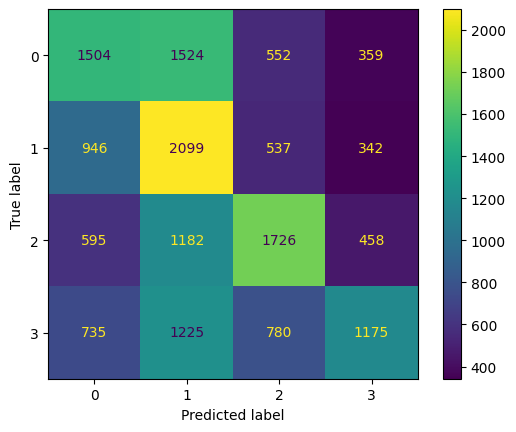

In [10]:
acc, y_true_train, y_pred = evaluate_model(clf, train_ds)
cm = confusion_matrix(y_true_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true_train, y_pred))

# Test Predictions

🧠 Test Accuracy: 0.3484
              precision    recall  f1-score   support

           0       0.32      0.30      0.31       862
           1       0.30      0.46      0.36       859
           2       0.41      0.38      0.39       866
           3       0.43      0.25      0.32       857

    accuracy                           0.35      3444
   macro avg       0.37      0.35      0.35      3444
weighted avg       0.37      0.35      0.35      3444



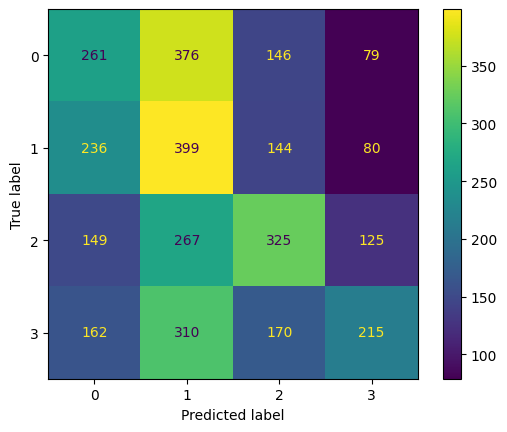

In [11]:
acc, y_true, y_pred = evaluate_model(clf, test_ds)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true, y_pred))